# P8 — Boosting Algorithms Benchmark

This corrected notebook compares AdaBoost, Gradient Boosting, XGBoost, and LightGBM when the corresponding libraries are available.

**Important:** XGBoost on macOS may require the OpenMP runtime. If XGBoost cannot be imported, the notebook will continue with the other models and clearly report the reason.

In [1]:
# 0. Imports and optional model availability
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

XGBClassifier = None
LGBMClassifier = None
xgb_import_error = None
lgb_import_error = None

try:
    from xgboost import XGBClassifier
    print('XGBoost import: successful')
except Exception as exc:
    xgb_import_error = exc
    print('XGBoost import: unavailable')
    print(type(exc).__name__ + ':', exc)

try:
    from lightgbm import LGBMClassifier
    print('LightGBM import: successful')
except Exception as exc:
    lgb_import_error = exc
    print('LightGBM import: unavailable')
    print(type(exc).__name__ + ':', exc)

XGBoost import: successful
LightGBM import: successful


## 1. Load the dataset

The notebook first checks the expected path. It supports the usual project structure where the notebook is inside `notebooks/` and the dataset is inside `data/`.

In [2]:
# 1. Load dataset
candidate_paths = [
    Path('../data/DT_Placement.csv'),
    Path('data/DT_Placement.csv'),
    Path('../data/placement_predict_50k Dataset_final.csv'),
    Path('data/placement_predict_50k Dataset_final.csv')
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        'Dataset not found. Put DT_Placement.csv in the data folder '
        'or update candidate_paths in this cell.'
    )

df = pd.read_csv(data_path)

print('Dataset path:', data_path)
print('Dataset shape:', df.shape)
display(df.head())
print('\nColumn names:')
print(df.columns.tolist())
print('\nMissing values:')
display(df.isna().sum().sort_values(ascending=False).head(15))


Dataset path: ../data/DT_Placement.csv
Dataset shape: (14, 6)


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,S1,8.6,2,No,73,Yes
1,S2,9.4,2,No,76,Yes
2,S3,9.0,2,No,81,Yes
3,S4,5.2,0,Yes,48,No
4,S5,5.3,0,Yes,44,No



Column names:
['ID', 'CGPA', 'Internships', 'Backlogs', 'Aptitude', 'Placed']

Missing values:


ID             0
CGPA           0
Internships    0
Backlogs       0
Aptitude       0
Placed         0
dtype: int64

## 2. Identify and prepare the target column

This cell supports either the small placement dataset (`Placed`) or the larger placement dataset (`PlacementStatus`). It does not apply a string mapping to an already numeric target.

In [3]:
# 2. Identify target and remove leakage/identifier columns
target_candidates = ['Placed', 'PlacementStatus', 'target', 'Target']
target_col = next((col for col in target_candidates if col in df.columns), None)

if target_col is None:
    raise KeyError(
        f'Could not find a target column. Available columns: {df.columns.tolist()}'
    )

def convert_binary_target(series):
    # Preserve an already numeric binary target.
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')

    cleaned = series.astype('string').str.strip().str.lower()
    mapping = {
        'no': 0, 'yes': 1,
        'not placed': 0, 'placed': 1,
        'false': 0, 'true': 1,
        '0': 0, '1': 1
    }
    return cleaned.map(mapping)

y = convert_binary_target(df[target_col])

if y.isna().any():
    bad_values = df.loc[y.isna(), target_col].drop_duplicates().tolist()
    raise ValueError(
        f'Target column {target_col!r} contains unmapped or missing values: {bad_values}'
    )

y = y.astype(int)

drop_columns = [target_col]
for col in ['ID', 'StudentID', 'Salary Package']:
    if col in df.columns:
        drop_columns.append(col)

X = df.drop(columns=drop_columns).copy()

print('Target column:', target_col)
print('Removed columns:', drop_columns)
print('\nTarget distribution:')
display(y.value_counts().sort_index())
print('\nFeature shape before encoding:', X.shape)

Target column: Placed
Removed columns: ['Placed', 'ID']

Target distribution:


Placed
0    6
1    8
Name: count, dtype: int64


Feature shape before encoding: (14, 4)


## 3. Encode categorical features and handle missing values

Tree-based boosting models require numeric input. Missing numeric values are filled with the training median, and categorical values are filled with the training mode before one-hot encoding.

In [4]:
# 3. Train-validation split before preprocessing to avoid data leakage
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

numeric_cols = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()

X_train = X_train_raw.copy()
X_val = X_val_raw.copy()

# Numeric imputation uses training-set medians only.
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)

# Categorical imputation uses training-set modes only.
for col in categorical_cols:
    mode_values = X_train[col].mode(dropna=True)
    fill_value = mode_values.iloc[0] if not mode_values.empty else 'Unknown'
    X_train[col] = X_train[col].fillna(fill_value)
    X_val[col] = X_val[col].fillna(fill_value)

# One-hot encode together so train and validation receive identical columns.
combined = pd.concat([X_train, X_val], axis=0)
combined = pd.get_dummies(combined, columns=categorical_cols, drop_first=False, dtype=int)

X_train = combined.iloc[:len(X_train)].copy()
X_val = combined.iloc[len(X_train):].copy()

X_train = X_train.astype(float)
X_val = X_val.astype(float)

print('Training samples:', len(X_train))
print('Validation samples:', len(X_val))
print('Encoded feature count:', X_train.shape[1])
print('Remaining missing values in X_train:', int(X_train.isna().sum().sum()))
print('Remaining missing values in X_val:', int(X_val.isna().sum().sum()))

Training samples: 9
Validation samples: 5
Encoded feature count: 5
Remaining missing values in X_train: 0
Remaining missing values in X_val: 0


## 4. AdaBoost: sample weights and estimator weights

In [5]:
# 4. AdaBoost sample-weight concept and model training
initial_weights = np.ones(len(X_train)) / len(X_train)
print('Initial sample weight for every training row:', initial_weights[0])
print('Sum of initial sample weights:', initial_weights.sum())

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_val)

print('AdaBoost validation accuracy:', accuracy_score(y_val, ada_pred))
print('\nAdaBoost estimator weights:')
for i, weight in enumerate(ada.estimator_weights_, start=1):
    print(f'Estimator {i}: {weight:.4f}')

Initial sample weight for every training row: 0.1111111111111111
Sum of initial sample weights: 1.0
AdaBoost validation accuracy: 0.6

AdaBoost estimator weights:
Estimator 1: 1.0397
Estimator 2: 0.7424
Estimator 3: 0.6414
Estimator 4: 0.6959
Estimator 5: 0.4541
Estimator 6: 0.4478
Estimator 7: 0.4812
Estimator 8: 0.4598
Estimator 9: 0.4587
Estimator 10: 0.3498


## 5. XGBoost with early stopping (optional)

This section runs only if XGBoost imported successfully. If macOS reports a missing `libomp.dylib`, install the OpenMP runtime in Terminal with `brew install libomp`, restart VS Code, and rerun the notebook.

In [6]:
# 5. XGBoost with early stopping, when available
xgb = None
if XGBClassifier is not None:
    xgb = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric='logloss',
        early_stopping_rounds=20,
        n_jobs=1
    )

    xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    xgb_pred = xgb.predict(X_val)
    print('XGBoost validation accuracy:', accuracy_score(y_val, xgb_pred))
    print('Best XGBoost iteration:', xgb.best_iteration)
else:
    print('XGBoost section skipped because the package could not be imported.')

XGBoost validation accuracy: 0.6
Best XGBoost iteration: 0


## 6. LightGBM training time (optional)

In [7]:
# 6. LightGBM training time, when available
lgb = None
lgb_time = None
if LGBMClassifier is not None:
    lgb = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbosity=-1,
        n_jobs=1
    )

    start_time = time.perf_counter()
    lgb.fit(X_train, y_train)
    lgb_time = time.perf_counter() - start_time

    lgb_pred = lgb.predict(X_val)
    print('LightGBM validation accuracy:', accuracy_score(y_val, lgb_pred))
    print(f'LightGBM training time: {lgb_time:.6f} seconds')
else:
    print('LightGBM section skipped because the package could not be imported.')

LightGBM validation accuracy: 0.6
LightGBM training time: 0.006694 seconds


## 7. Boosting benchmark function

The function returns a DataFrame. The returned value is assigned to `results_df` when the function is called, so there is no undefined `results` or `results_df` variable.

In [8]:
# 7. Correct benchmark function
def boosting_benchmark(X_train, y_train, X_val, y_val):
    models = {
        'AdaBoost': AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    }

    if XGBClassifier is not None:
        models['XGBoost'] = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric='logloss',
                
            n_jobs=1
        )

    if LGBMClassifier is not None:
        models['LightGBM'] = LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1,
            n_jobs=1
        )

    results = []

    for name, model in models.items():
        start_time = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = time.perf_counter() - start_time

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        results.append({
            'model': name,
            'train_accuracy': accuracy_score(y_train, train_pred),
            'val_accuracy': accuracy_score(y_val, val_pred),
            'training_time_sec': train_time
        })

    return pd.DataFrame(results).sort_values(
        by='val_accuracy',
        ascending=False
    ).reset_index(drop=True)

In [9]:
# 8. Run and display benchmark
results_df = boosting_benchmark(X_train, y_train, X_val, y_val)

print('==========================================')
print('BOOSTING BENCHMARK RESULTS')
print('==========================================')
display(results_df)

BOOSTING BENCHMARK RESULTS


,model,train_accuracy,val_accuracy,training_time_sec
0,AdaBoost,1.000000,0.8,0.087885
1,GradientBoosting,1.000000,0.6,0.038176
2,XGBoost,0.555556,0.6,0.006005
3,LightGBM,0.555556,0.6,0.001959


## 9. Validation accuracy comparison

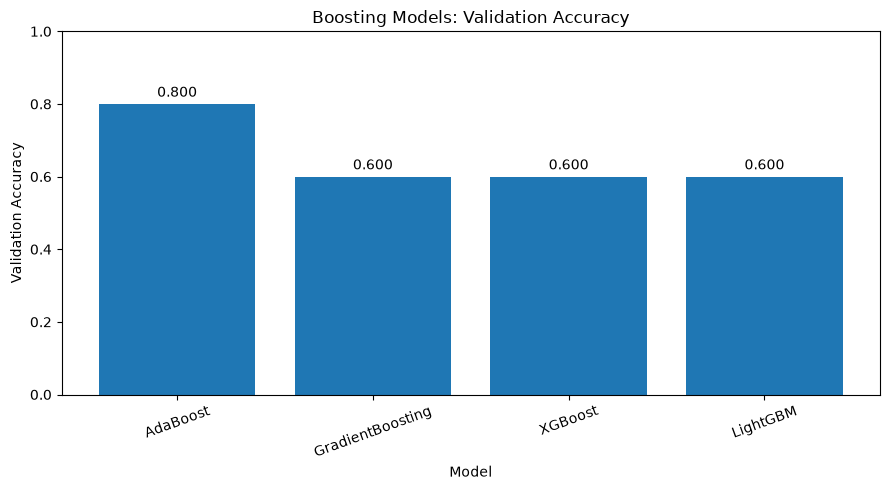

In [10]:
# 9. Plot actual benchmark results (not placeholder v1/v2 values)
plt.figure(figsize=(9, 5))
plt.bar(results_df['model'], results_df['val_accuracy'])
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.title('Boosting Models: Validation Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)

for i, value in enumerate(results_df['val_accuracy']):
    plt.text(i, value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 10. Optional SHAP explanation

SHAP is not required for the benchmark to work. Run the next cell only if the `shap` package is installed and an XGBoost model was successfully trained.

In [11]:
# 10. Optional SHAP plot
if xgb is None:
    print('SHAP skipped because XGBoost is unavailable.')
else:
    try:
        import shap
        shap_values = shap.TreeExplainer(xgb).shap_values(X_val)
        plt.figure(figsize=(8, 5))
        shap.summary_plot(shap_values, X_val, plot_type='dot', show=False)
        plt.title('XGBoost SHAP Beeswarm Plot')
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print('SHAP plot skipped:', type(exc).__name__ + ':', exc)

SHAP plot skipped: ModuleNotFoundError: No module named 'shap'
